# Estimación de velocidad multivideo con calibración por carril

Notebook liviano que usa funciones de `src/` para:

- Generar CSV de tracks con YOLO cuando faltan.
- Matchear radar ↔ tracks y estimar velocidad cruda por vehículo.
- Calibrar factores por carril usando un video de referencia.
- Evaluar métricas por video y generar gráficos para el informe.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.config import VIDEO_NAMES, CALIB_VIDEO
from src.speed_estimation import process_video
from src.metrics import evaluate_predictions, calibrate_lane_scales
from src.visualization import (
    scatter_real_vs_est,
    plot_speed_error_hist,
    plot_speed_by_lane_boxplot,
    plot_metric_bar,
)

VIDEO_NAMES, CALIB_VIDEO


(['video01', 'video02', 'video03', 'video04'], 'video03')

In [3]:
videos_eval_raw = {}

for v in VIDEO_NAMES:
    print("=" * 60)
    print(f"Procesando {v}")
    df_eval_v = process_video(v, min_frames=5, use_axis="y")
    videos_eval_raw[v] = df_eval_v
    print(f"{v}: {df_eval_v.shape[0]} vehículos con predicción cruda")

videos_eval_raw[CALIB_VIDEO].head()


Procesando video01
video01: 102 vehículos con predicción cruda
Procesando video02
video02: 130 vehículos con predicción cruda
Procesando video03
video03: 441 vehículos con predicción cruda
Procesando video04
video04: 134 vehículos con predicción cruda


,gt_id,vehicle_id,lane,speed_raw,gt_speed,frame_start,frame_end,delta_frames,n_points,match_iou
0,1,1,3,681.198671,43.19,6,46,40,33,0.006869
1,2,40,3,11.065063,43.63,85,125,40,5,0.040301
2,4,41,2,925.460034,55.61,124,164,40,26,0.010503
3,5,40,3,822.074604,50.17,129,169,40,29,0.005622
4,6,52,1,808.633285,47.28,145,185,40,27,0.041631


In [4]:
rows_raw = []

for v in VIDEO_NAMES:
    df_eval_v = videos_eval_raw[v]
    if df_eval_v.shape[0] == 0:
        continue
    metrics_v = evaluate_predictions(
        df_eval_v,
        pred_col="speed_raw",
        gt_col="gt_speed",
        verbose=False,
    )
    metrics_v["video"] = v
    rows_raw.append(metrics_v)

df_metrics_raw = pd.DataFrame(rows_raw).set_index("video") if rows_raw else pd.DataFrame()
df_metrics_raw


,mae,rmse,mape,r2,n_samples
video,,,,,
video01,679.388735,736.347670,1497.502766,-4645.380366,102
video02,556.599625,637.318643,1224.273646,-3996.999683,130
video03,549.338680,637.376576,1269.485812,-3661.542851,441
video04,665.267830,727.385999,1367.912748,-4774.895457,134


In [5]:
df_eval_calib_video = videos_eval_raw[CALIB_VIDEO].copy()
print(f"{CALIB_VIDEO}: {df_eval_calib_video.shape[0]} vehículos para calibrar")

lane_scales = calibrate_lane_scales(
    df_eval=df_eval_calib_video,
    pred_col="speed_raw",
    gt_col="gt_speed",
    lane_col="lane",
    min_samples=4,
)

lane_scales


video03: 441 vehículos para calibrar


{1: 0.05842461038175043, 2: 0.056792858646254815, 3: 0.060405562791286116}

In [6]:
videos_eval_calib = {}

for v in VIDEO_NAMES:
    df_eval_v = videos_eval_raw[v].copy()
    if df_eval_v.shape[0] == 0:
        videos_eval_calib[v] = df_eval_v
        continue

    df_eval_v["speed_kmh"] = df_eval_v.apply(
        lambda r: r["speed_raw"] * lane_scales.get(r["lane"], 1.0),
        axis=1,
    )

    df_eval_v = df_eval_v[df_eval_v["speed_kmh"] >= 10.0]

    videos_eval_calib[v] = df_eval_v

videos_eval_calib[CALIB_VIDEO].head()


,gt_id,vehicle_id,lane,speed_raw,gt_speed,frame_start,frame_end,delta_frames,n_points,match_iou,speed_kmh
0,1,1,3,681.198671,43.19,6,46,40,33,0.006869,41.148189
2,4,41,2,925.460034,55.61,124,164,40,26,0.010503,52.559521
3,5,40,3,822.074604,50.17,129,169,40,29,0.005622,49.657879
4,6,52,1,808.633285,47.28,145,185,40,27,0.041631,47.244085
5,7,52,1,759.851048,47.14,170,210,40,31,0.007944,44.394001


In [7]:
rows_cal = []

for v in VIDEO_NAMES:
    df_eval_cal_v = videos_eval_calib[v]
    if df_eval_cal_v.shape[0] == 0:
        continue

    metrics_v = evaluate_predictions(
        df_eval_cal_v,
        pred_col="speed_kmh",
        gt_col="gt_speed",
        verbose=False,
    )
    metrics_v["video"] = v
    rows_cal.append(metrics_v)

df_metrics_cal = pd.DataFrame(rows_cal).set_index("video") if rows_cal else pd.DataFrame()
df_metrics_cal


,mae,rmse,mape,r2,n_samples
video,,,,,
video01,4.224530,7.125089,9.189059,0.533187,93
video02,4.186592,7.375699,8.923989,0.387874,103
video03,5.057237,8.578877,11.765037,0.331996,355
video04,5.621699,10.049448,11.749632,0.072088,121


In [8]:
if df_metrics_raw.empty or df_metrics_cal.empty:
    print("Alguna de las tablas de métricas está vacía; no se puede comparar crudo vs calibrado.")
    df_compare = pd.DataFrame()
else:
    df_compare = df_metrics_raw.join(
        df_metrics_cal,
        how="inner",
        lsuffix="_raw",
        rsuffix="_cal",
    )

df_compare


,mae_raw,rmse_raw,mape_raw,r2_raw,n_samples_raw,mae_cal,rmse_cal,mape_cal,r2_cal,n_samples_cal
video,,,,,,,,,,
video01,679.388735,736.347670,1497.502766,-4645.380366,102,4.224530,7.125089,9.189059,0.533187,93
video02,556.599625,637.318643,1224.273646,-3996.999683,130,4.186592,7.375699,8.923989,0.387874,103
video03,549.338680,637.376576,1269.485812,-3661.542851,441,5.057237,8.578877,11.765037,0.331996,355
video04,665.267830,727.385999,1367.912748,-4774.895457,134,5.621699,10.049448,11.749632,0.072088,121


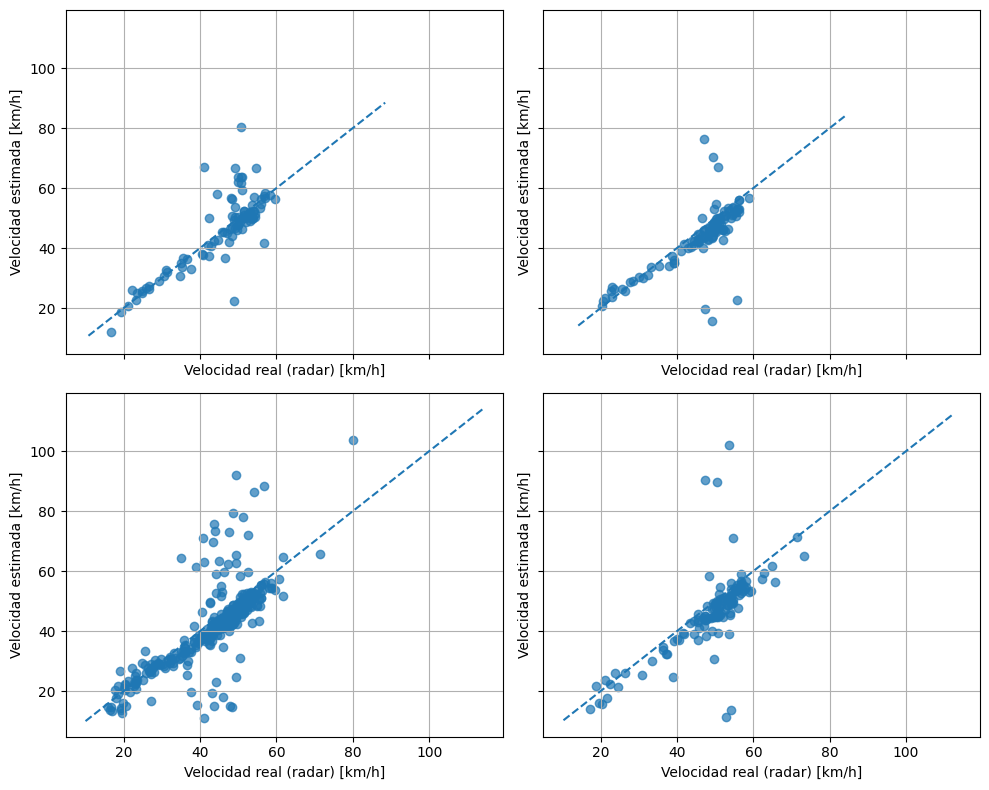

In [9]:
fig_rows = 2
fig_cols = 2
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

for idx, v in enumerate(VIDEO_NAMES):
    if idx >= len(axes):
        break
    ax = axes[idx]
    df_eval_cal_v = videos_eval_calib[v]
    if df_eval_cal_v.shape[0] == 0:
        ax.axis("off")
        continue

    scatter_real_vs_est(
        df_eval_cal_v,
        pred_col="speed_kmh",
        gt_col="gt_speed",
        ax=ax,
    )

plt.tight_layout()
plt.show()


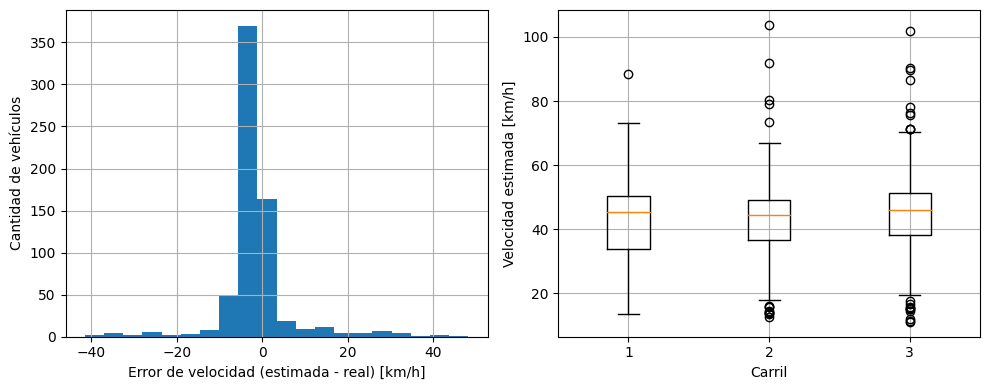

In [10]:
df_all = pd.concat(
    [df.assign(video=v) for v, df in videos_eval_calib.items() if df.shape[0] > 0],
    ignore_index=True,
) if any(df.shape[0] > 0 for df in videos_eval_calib.values()) else pd.DataFrame()

if df_all.empty:
    print("No hay datos calibrados para graficar errores y distribuciones.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    plot_speed_error_hist(df_all, pred_col="speed_kmh", gt_col="gt_speed", ax=axes[0])
    plot_speed_by_lane_boxplot(df_all, speed_col="speed_kmh", lane_col="lane", ax=axes[1])

    plt.tight_layout()
    plt.show()


Con este notebook se obtiene:

- Velocidad cruda por vehículo a partir de YOLO + radar.
- Calibración por carril usando un video de referencia.
- Métricas por video para velocidad cruda y calibrada.
- Gráficos listos para incluir en el informe (dispersión, errores, boxplots, barras).

Si se cambian los videos o el video de calibración, se actualizan en `src/speed_config.py`.
